# Concrete Slump Test Regression

The concrete slump test measures the consistency of fresh concrete before it sets. It is performed to check the workability of freshly made concrete, and therefore the ease with which concrete flows. It can also be used as an indicator of an improperly mixed batch.

<img src="https://i0.wp.com/civiconcepts.com/wp-content/uploads/2019/08/Slump-Cone-test-of-concrete.jpg?fit=977%2C488&ssl=1">

Our data set consists of various cement properties and the resulting slump test metrics in cm. Later on the set concrete is tested for its compressive strength 28 days later.

Input variables (9):

(component kg in one M^3 concrete)(7):
* Cement
* Slag
* Fly ash
* Water
* SP
* Coarse Aggr.
* Fine Aggr.

(Measurements)(2)
* SLUMP (cm)
* FLOW (cm)

Target variable (1):
* **28-day Compressive Strength (Mpa)**

Data Source: https://archive.ics.uci.edu/ml/datasets/Concrete+Slump+Test

*Credit: Yeh, I-Cheng, "Modeling slump flow of concrete using second-order regressions and artificial neural networks," Cement and Concrete Composites, Vol.29, No. 6, 474-480, 2007.*

# Importing dependencies

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#%matplotlib inline
#%matplotlib notebook
plt.rcParams["figure.figsize"] = (10,6)
import warnings
warnings.filterwarnings("ignore")
warnings.warn("this will not show")
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Loading data

In [2]:
df = pd.read_csv('cement_slump.csv')

In [3]:
df.head(5)

,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.,SLUMP(cm),FLOW(cm),Compressive Strength (28-day)(Mpa)
0,273.000,82.000,105.000,210.000,9.000,904.000,680.000,23.000,62.000,34.990
1,163.000,149.000,191.000,180.000,12.000,843.000,746.000,0.000,20.000,41.140
2,162.000,148.000,191.000,179.000,16.000,840.000,743.000,1.000,20.000,41.810
3,162.000,148.000,190.000,179.000,19.000,838.000,741.000,3.000,21.500,42.080
4,154.000,112.000,144.000,220.000,10.000,923.000,658.000,20.000,64.000,26.820


In [4]:
df.shape

(103, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 10 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Cement                              103 non-null    float64
 1   Slag                                103 non-null    float64
 2   Fly ash                             103 non-null    float64
 3   Water                               103 non-null    float64
 4   SP                                  103 non-null    float64
 5   Coarse Aggr.                        103 non-null    float64
 6   Fine Aggr.                          103 non-null    float64
 7   SLUMP(cm)                           103 non-null    float64
 8   FLOW(cm)                            103 non-null    float64
 9   Compressive Strength (28-day)(Mpa)  103 non-null    float64
dtypes: float64(10)
memory usage: 8.2 KB


In [6]:
df.describe()

,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.,SLUMP(cm),FLOW(cm),Compressive Strength (28-day)(Mpa)
count,103.000,103.000,103.000,103.000,103.000,103.000,103.000,103.000,103.000,103.000
mean,229.894,77.974,149.015,197.168,8.540,883.979,739.605,18.049,49.611,36.039
std,78.877,60.461,85.418,20.208,2.808,88.391,63.342,8.751,17.569,7.837
min,137.000,0.000,0.000,160.000,4.400,708.000,640.600,0.000,20.000,17.190
25%,152.000,0.050,115.500,180.000,6.000,819.500,684.500,14.500,38.500,30.900
50%,248.000,100.000,164.000,196.000,8.000,879.000,742.700,21.500,54.000,35.520
75%,303.900,125.000,235.950,209.500,10.000,952.800,788.000,24.000,63.750,41.205
max,374.000,193.000,260.000,240.000,19.000,1049.900,902.000,29.000,78.000,58.530


# EDA and Graphical analysis

<AxesSubplot:xlabel='SLUMP(cm)'>

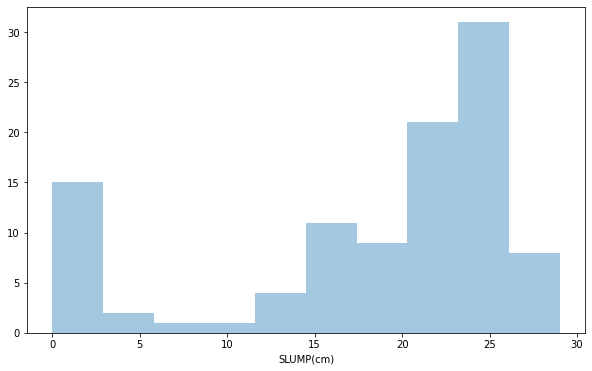

In [7]:
sns.distplot(df['SLUMP(cm)'], bins=10,kde=False)

<AxesSubplot:xlabel='FLOW(cm)'>

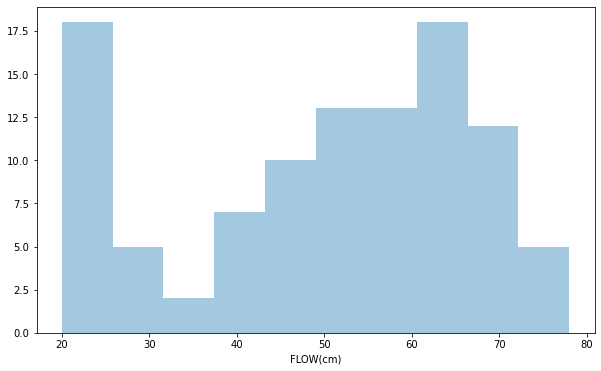

In [8]:
sns.distplot(df['FLOW(cm)'], bins=10,kde=False)

<AxesSubplot:xlabel='Compressive Strength (28-day)(Mpa)'>

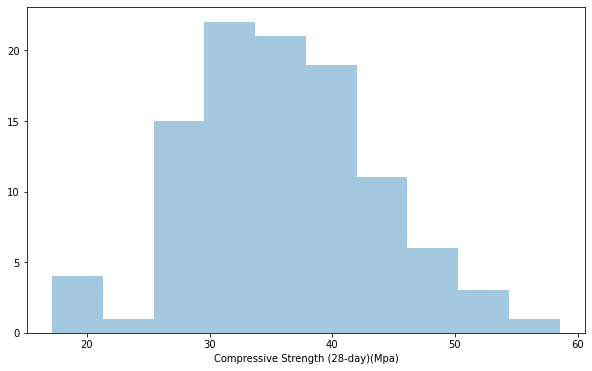

In [9]:
sns.distplot(df['Compressive Strength (28-day)(Mpa)'], bins=10,kde=False)

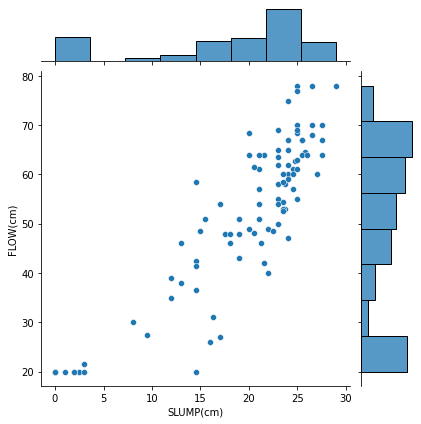

In [10]:
sns.jointplot(df['SLUMP(cm)'], df['FLOW(cm)'])

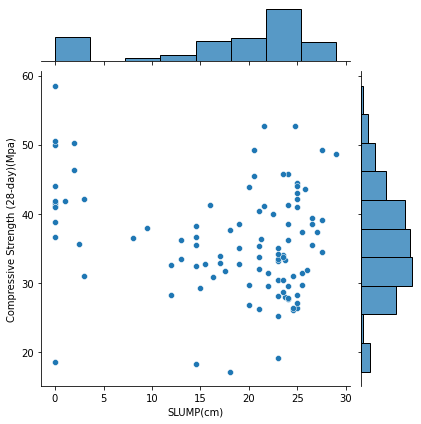

In [11]:
sns.jointplot(df['SLUMP(cm)'], df['Compressive Strength (28-day)(Mpa)'])

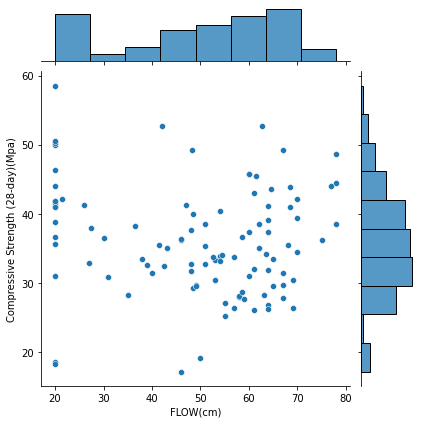

In [12]:
sns.jointplot(df['FLOW(cm)'], df['Compressive Strength (28-day)(Mpa)'])

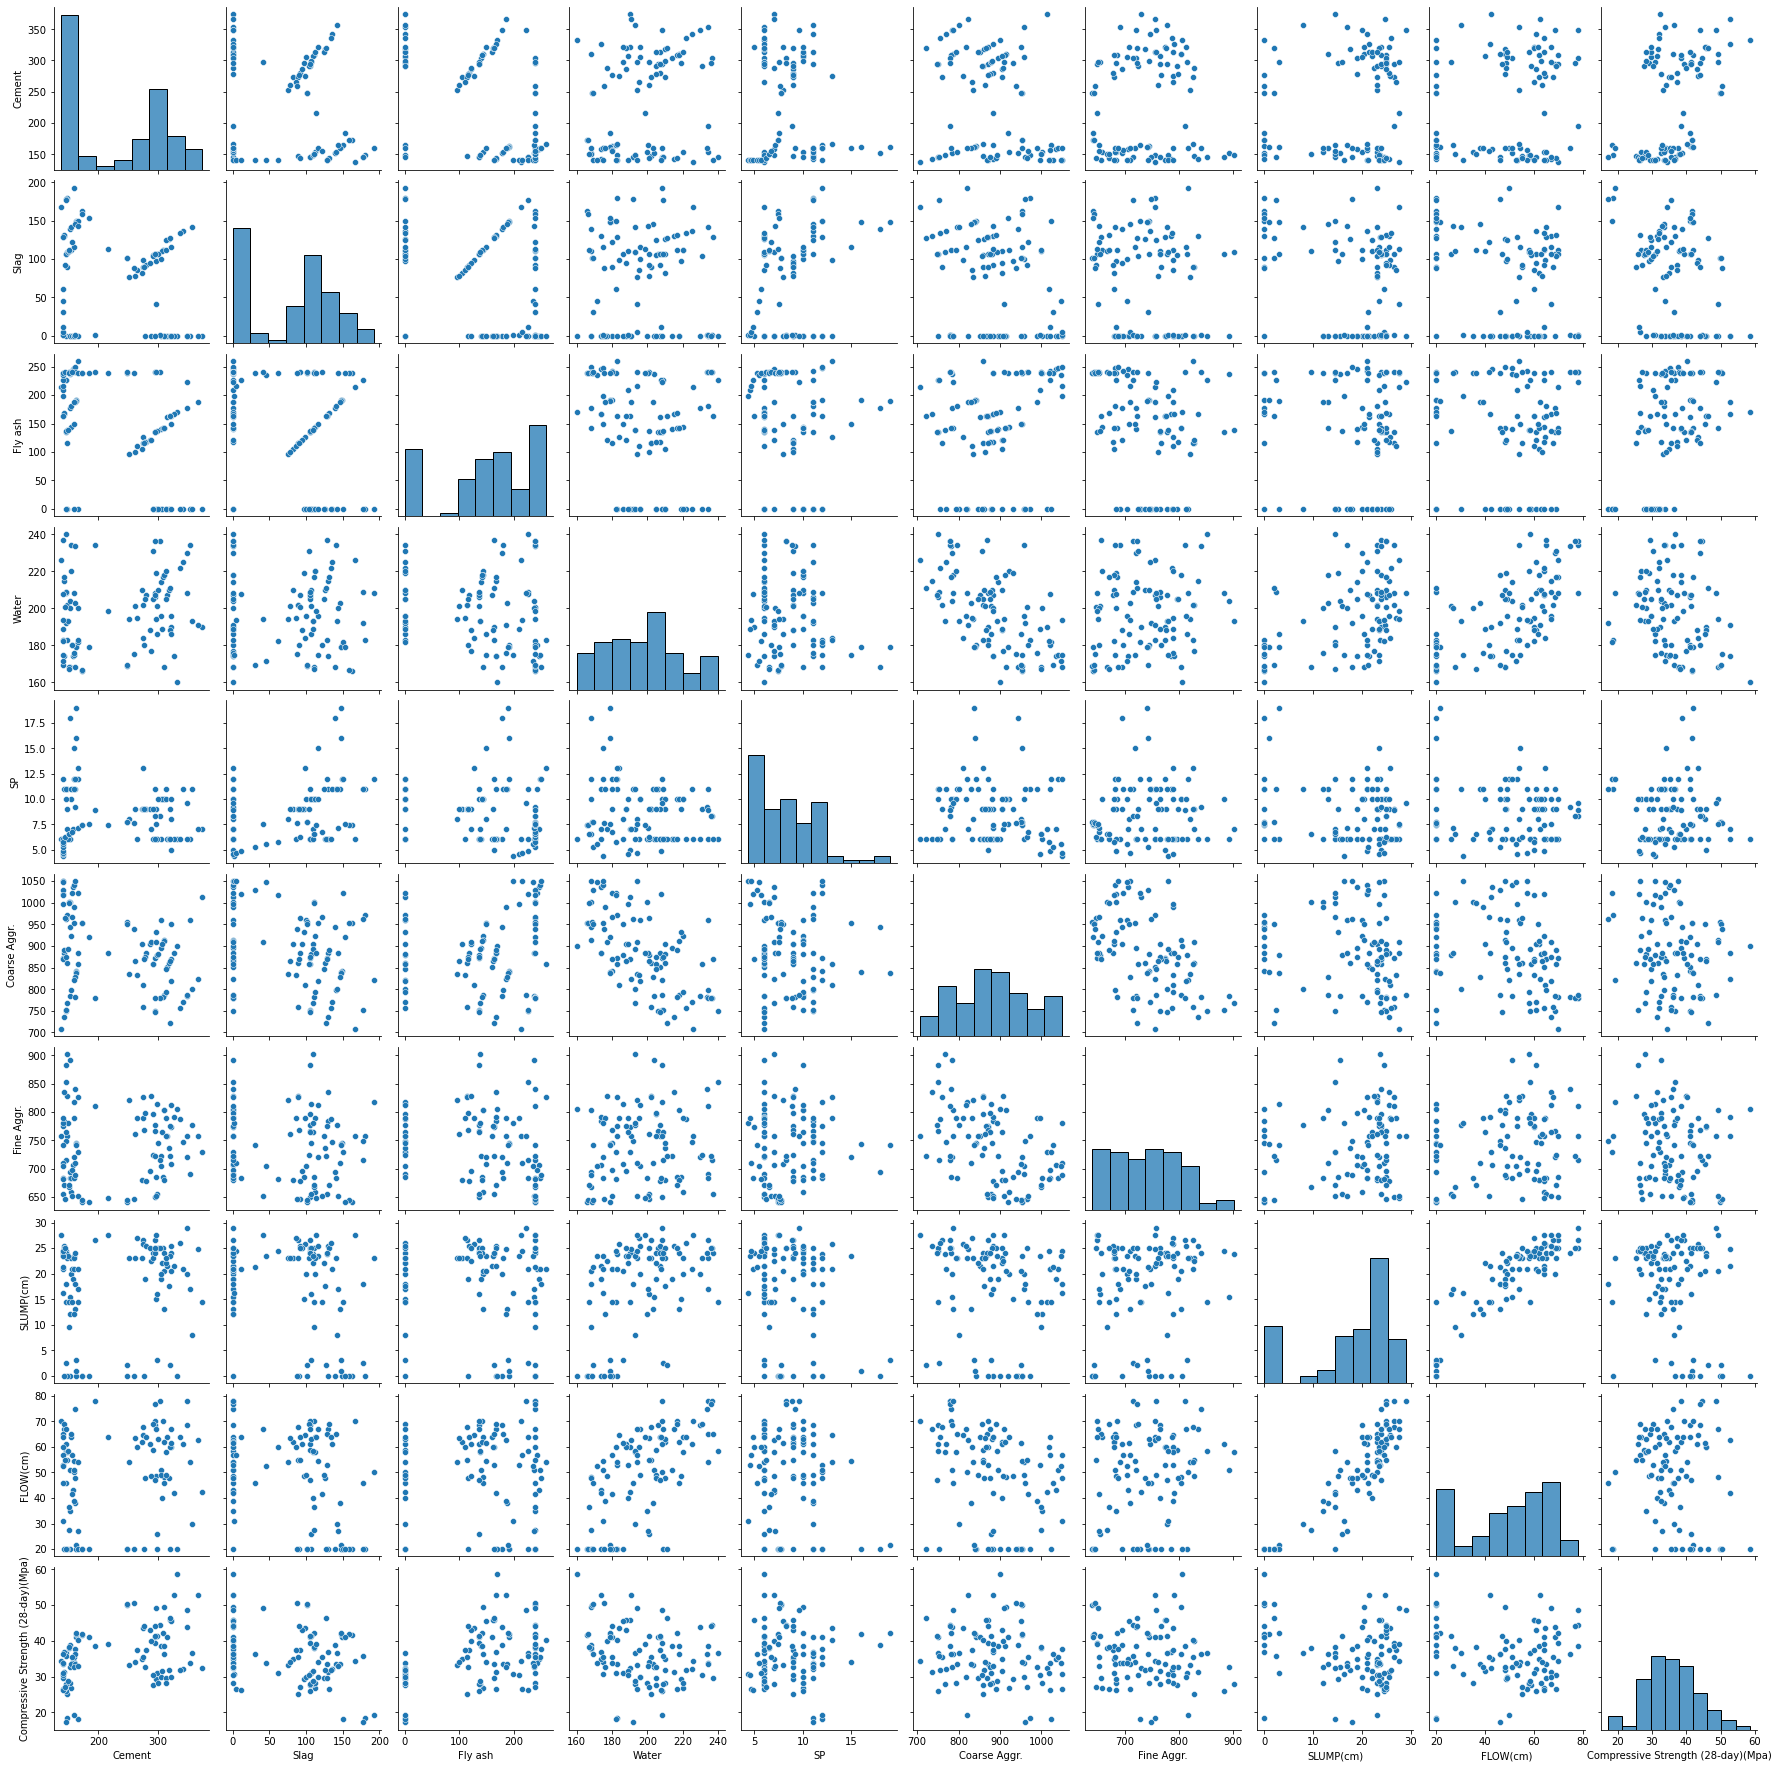

In [13]:
sns.pairplot(df)

In [14]:
df.corr()

,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.,SLUMP(cm),FLOW(cm),Compressive Strength (28-day)(Mpa)
Cement,1.000,-0.244,-0.487,0.221,-0.106,-0.310,0.057,0.146,0.186,0.446
Slag,-0.244,1.000,-0.323,-0.027,0.307,-0.224,-0.184,-0.284,-0.327,-0.332
Fly ash,-0.487,-0.323,1.000,-0.241,-0.144,0.173,-0.283,-0.119,-0.055,0.444
Water,0.221,-0.027,-0.241,1.000,-0.155,-0.602,0.115,0.467,0.632,-0.254
SP,-0.106,0.307,-0.144,-0.155,1.000,-0.104,0.058,-0.213,-0.176,-0.038
Coarse Aggr.,-0.310,-0.224,0.173,-0.602,-0.104,1.000,-0.489,-0.188,-0.326,-0.161
Fine Aggr.,0.057,-0.184,-0.283,0.115,0.058,-0.489,1.000,0.202,0.190,-0.155
SLUMP(cm),0.146,-0.284,-0.119,0.467,-0.213,-0.188,0.202,1.000,0.906,-0.223
FLOW(cm),0.186,-0.327,-0.055,0.632,-0.176,-0.326,0.190,0.906,1.000,-0.124
Compressive Strength (28-day)(Mpa),0.446,-0.332,0.444,-0.254,-0.038,-0.161,-0.155,-0.223,-0.124,1.000


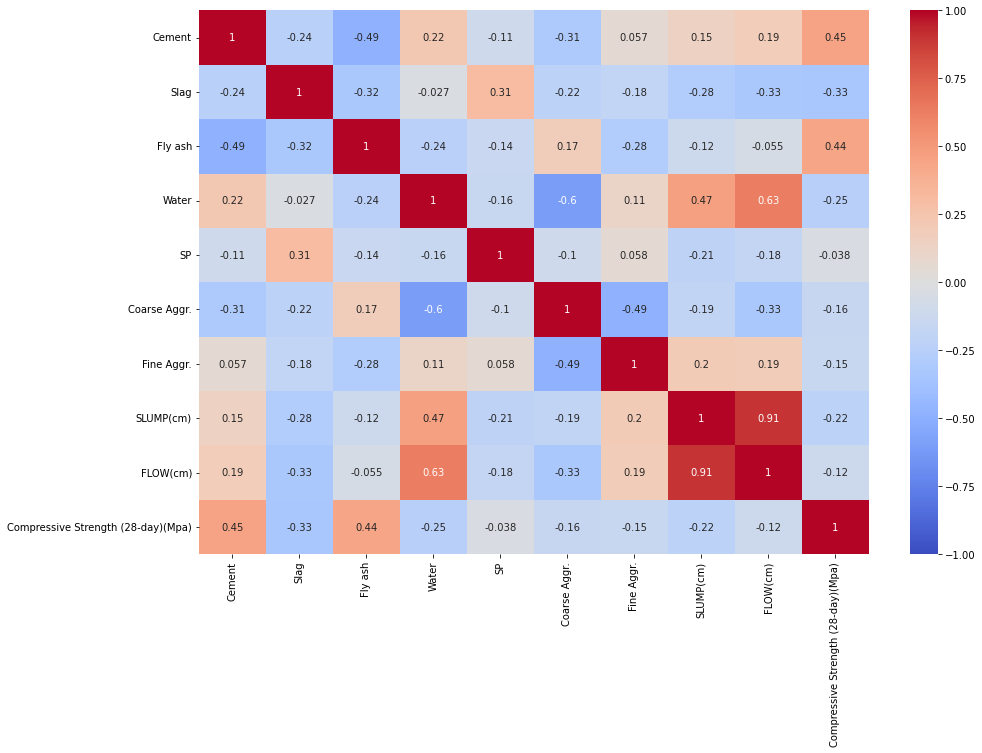

In [15]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=True,cmap='coolwarm', vmin=-1, vmax=1);

In [16]:
#Slump and Flow has the strongest positive correlation. Water has the strongest positive correlation with SLUMP and FLOW
#but has a negative correlation with the Compressive Strenght. So we can say you can increase the SLUMP and FLOW by adding 
#more water while reducing the Compressive Strenght.

# Data Preprocessing 

### Features and target variable

In [17]:
df.head(5)

,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.,SLUMP(cm),FLOW(cm),Compressive Strength (28-day)(Mpa)
0,273.000,82.000,105.000,210.000,9.000,904.000,680.000,23.000,62.000,34.990
1,163.000,149.000,191.000,180.000,12.000,843.000,746.000,0.000,20.000,41.140
2,162.000,148.000,191.000,179.000,16.000,840.000,743.000,1.000,20.000,41.810
3,162.000,148.000,190.000,179.000,19.000,838.000,741.000,3.000,21.500,42.080
4,154.000,112.000,144.000,220.000,10.000,923.000,658.000,20.000,64.000,26.820


In [18]:
X = df[['Cement','Slag','Fly ash','Water','SP','Coarse Aggr.', 'Fine Aggr.']] #features

In [19]:
y1 = df['SLUMP(cm)'] #target1

In [20]:
y2 = df['FLOW(cm)'] #target2

In [21]:
y3 = df['Compressive Strength (28-day)(Mpa)'] #target3

### Splitting data into training and testing

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y3, test_size=0.3, random_state=101)

In [43]:
X_train_cols = X.columns
X_test_cols = X.columns

## Scaling

In [25]:
from sklearn.preprocessing import StandardScaler
from scipy import stats

In [26]:
ss = StandardScaler()
X_train= pd.DataFrame(ss.fit_transform(X_train))
X_train.set_index(X_train.index, inplace = True)
X_train.columns = X_train_cols
X_train.head()

,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.
0,-0.976,0.488,1.029,-1.530,-0.843,1.369,-1.002
1,-0.925,0.998,0.316,1.942,1.108,-0.957,-0.822
2,-1.035,1.636,-1.915,-0.244,1.108,0.927,0.125
3,1.195,0.481,-0.164,1.057,0.674,-1.117,-0.779
4,-1.008,1.671,-1.915,-0.713,1.108,1.053,0.240


In [44]:
X_test= pd.DataFrame(ss.fit_transform(X_test))
X_test.set_index(X_test.index, inplace = True)
X_test.columns = X_test_cols
X_test.head()

,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.
0,-0.974,1.325,-1.465,-0.739,0.882,1.460,-0.206
1,-0.997,1.310,0.618,-0.830,0.882,-0.554,0.180
2,0.983,1.073,-1.465,1.078,-0.752,-1.527,1.113
3,-1.259,-0.975,0.889,-0.198,-1.105,1.756,-0.636
4,0.614,-1.038,1.150,1.732,-0.126,-1.257,-0.518


In [27]:
#X_train = X_train[(np.abs(stats.zscore(X_train)) < 2.5).all(axis = 1)]

In [28]:
#y_train = y_train.loc[X_train.index]

In [29]:
#X_train.describe()

In [30]:
#tried to remove outliers

##  1. Model Building (Linear Regression)

In [31]:
from sklearn.linear_model import LinearRegression

In [32]:
lm=LinearRegression()  # create a model object

In [33]:
lm.fit(X_train, y_train) # We use train data to fit the model

LinearRegression()

In [34]:
print('Coefficients: \n', lm.coef_)
print('Intercept: \n', lm.intercept_)

Coefficients: 
 [ 5.11068891 -1.01931784  4.83409277 -3.31418327  0.0910641  -3.51087256
 -1.8518292 ]
Intercept: 
 35.93972222222222


### 1.1 Interpret the model

In [35]:
predictions = lm.predict(X_test)

predictions_train = lm.predict(X_train)

Text(0, 0.5, 'PRedictions Y')

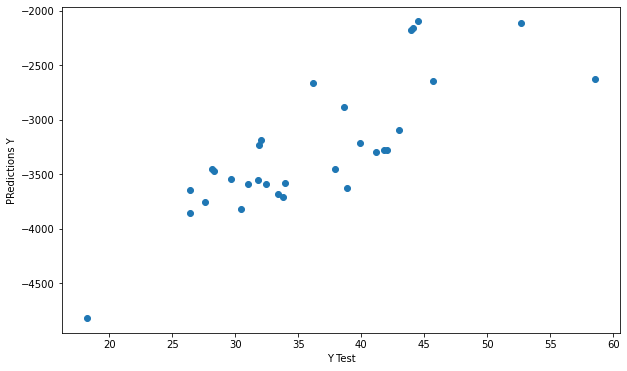

In [36]:
plt.scatter(y_test,predictions)
plt.xlabel('Y Test')
plt.ylabel('PRedictions Y')

### 1.2 Model Evaluation

In [37]:
from sklearn import metrics
print("test metrics:")
print("R2:", metrics.r2_score(y_test, predictions))
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

print("train metrics:")
print("R2:", metrics.r2_score(y_train, predictions_train))
print('MAE:', metrics.mean_absolute_error(y_train, predictions_train))
print('MSE:', metrics.mean_squared_error(y_train, predictions_train))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_train, predictions_train)))

test metrics:
R2: -163748.56169507245
MAE: 3296.459511326712
MSE: 11212798.504633473
RMSE: 3348.551702547457
train metrics:
R2: 0.9020730886630832
MAE: 1.8338643481964132
MSE: 5.630534623771204
RMSE: 2.3728747593944366


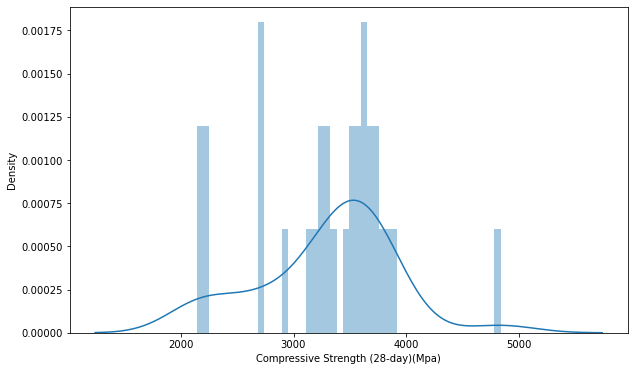

In [38]:
sns.distplot((y_test-predictions),bins=50);

In [39]:
coefficients = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
coefficients

,Coefficient
Cement,5.111
Slag,-1.019
Fly ash,4.834
Water,-3.314
SP,0.091
Coarse Aggr.,-3.511
Fine Aggr.,-1.852


# 2. Regularization

## 2.1 Ridge (Apply and evaluate)

In [40]:
from sklearn.linear_model import Ridge

In [41]:
ridge_model = Ridge(alpha=1, random_state=42)

In [42]:
ridge_model.fit(X_train, y_train)

Ridge(alpha=1, random_state=42)

In [50]:
y_pred = ridge_model.predict(X_test)
y_train_pred = ridge_model.predict(X_train)

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def train_val(y_train, y_train_pred, y_test, y_pred, i):
    
    scores = {i+"_train": {"R2" : r2_score(y_train, y_train_pred),
    "mae" : mean_absolute_error(y_train, y_train_pred),
    "mse" : mean_squared_error(y_train, y_train_pred),                          
    "rmse" : np.sqrt(mean_squared_error(y_train, y_train_pred))},
    
    i+"_test": {"R2" : r2_score(y_test, y_pred),
    "mae" : mean_absolute_error(y_test, y_pred),
    "mse" : mean_squared_error(y_test, y_pred),
    "rmse" : np.sqrt(mean_squared_error(y_test, y_pred))}}
    
    return pd.DataFrame(scores)

In [48]:
ls =train_val(y_train, y_train_pred, y_test, y_pred, "linear")
ls

,linear_train,linear_test
R2,0.902,0.810
mae,1.820,2.709
mse,5.655,12.985
rmse,2.378,3.604


In [51]:
rs = train_val(y_train, y_train_pred, y_test, y_pred, "ridge")
rs

,ridge_train,ridge_test
R2,0.902,0.810
mae,1.820,2.709
mse,5.655,12.985
rmse,2.378,3.604


In [52]:
pd.concat([ls, rs], axis=1)

,linear_train,linear_test,ridge_train,ridge_test
R2,0.902,0.810,0.902,0.810
mae,1.820,2.709,1.820,2.709
mse,5.655,12.985,5.655,12.985
rmse,2.378,3.604,2.378,3.604


In [54]:
from sklearn.model_selection import cross_validate, cross_val_score

In [55]:
model = Ridge(alpha=1, random_state=42)
scores = cross_validate(model, X_train, y_train,
                    scoring=['r2', 'neg_mean_absolute_error','neg_mean_squared_error','neg_root_mean_squared_error'], cv=5)

In [56]:
pd.DataFrame(scores, index = range(1, 6))

,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_mean_squared_error,test_neg_root_mean_squared_error
1,0.002,0.002,0.933,-1.754,-6.073,-2.464
2,0.002,0.002,0.902,-2.059,-7.725,-2.779
3,0.003,0.002,0.207,-2.444,-9.641,-3.105
4,0.002,0.001,0.833,-2.284,-7.593,-2.756
5,0.002,0.001,0.864,-2.009,-6.479,-2.545


In [57]:
scores = pd.DataFrame(scores, index = range(1, 6))
scores.iloc[:,2:].mean()

test_r2                             0.748
test_neg_mean_absolute_error       -2.110
test_neg_mean_squared_error        -7.502
test_neg_root_mean_squared_error   -2.730
dtype: float64

In [58]:
train_val(y_train, y_train_pred, y_test, y_pred, "ridge")

,ridge_train,ridge_test
R2,0.902,0.810
mae,1.820,2.709
mse,5.655,12.985
rmse,2.378,3.604


<AxesSubplot:>

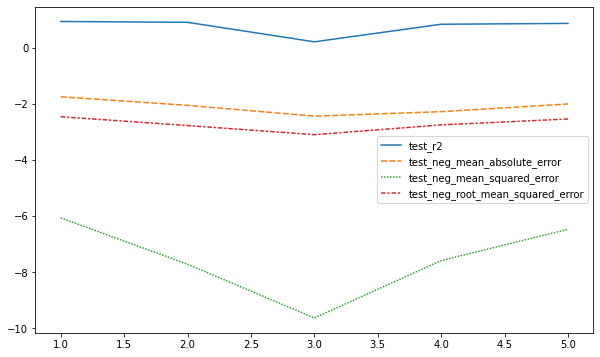

In [59]:
sns.lineplot(data = scores.iloc[:,2:])

In [60]:
ridge_model.coef_

array([ 5.07919856, -0.95367717,  4.79915124, -3.16563739,  0.0760452 ,
       -3.29600614, -1.73740798])

In [63]:
lm_df = pd.DataFrame(lm.coef_, columns = ["lm_coef"])
lm_df

,lm_coef
0,5.111
1,-1.019
2,4.834
3,-3.314
4,0.091
5,-3.511
6,-1.852


In [61]:
rm_df = pd.DataFrame(ridge_model.coef_, columns = ["ridge_coef_1"])

In [64]:
pd.concat([lm_df,rm_df], axis = 1)

,lm_coef,ridge_coef_1
0,5.111,5.079
1,-1.019,-0.954
2,4.834,4.799
3,-3.314,-3.166
4,0.091,0.076
5,-3.511,-3.296
6,-1.852,-1.737


In [65]:
from sklearn.linear_model import RidgeCV

In [66]:
alpha_space = np.linspace(0.01, 1, 100)
alpha_space

array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
       0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22,
       0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33,
       0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44,
       0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54, 0.55,
       0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66,
       0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77,
       0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88,
       0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99,
       1.  ])

In [67]:
ridge_cv_model = RidgeCV(alphas=alpha_space, cv = 5, scoring= "neg_root_mean_squared_error")

In [68]:
ridge_cv_model.fit(X_train, y_train)

RidgeCV(alphas=array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
       0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22,
       0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33,
       0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44,
       0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54, 0.55,
       0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66,
       0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77,
       0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88,
       0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99,
       1.  ]),
        cv=5, scoring='neg_root_mean_squared_error')

In [69]:
ridge_cv_model.alpha_ #Ridge(alpha=0.02)

0.8300000000000001

In [70]:
#rmse for ridge with CV
ridge_cv_model.best_score_

-2.729546104312547

In [71]:
y_pred = ridge_cv_model.predict(X_test)
y_train_pred = ridge_cv_model.predict(X_train)

In [72]:
rcs = train_val(y_train, y_train_pred, y_test, y_pred, "ridge_cv")
rcs

,ridge_cv_train,ridge_cv_test
R2,0.902,0.812
mae,1.822,2.700
mse,5.648,12.890
rmse,2.376,3.590


In [73]:
pd.concat([ls, rs, rcs], axis = 1)

,linear_train,linear_test,ridge_train,ridge_test,ridge_cv_train,ridge_cv_test
R2,0.902,0.810,0.902,0.810,0.902,0.812
mae,1.820,2.709,1.820,2.709,1.822,2.700
mse,5.655,12.985,5.655,12.985,5.648,12.890
rmse,2.378,3.604,2.378,3.604,2.376,3.590


In [74]:
ridge_cv_model.coef_

array([ 5.09398406, -0.95407931,  4.815754  , -3.18231003,  0.07971395,
       -3.31780766, -1.74488899])

In [75]:
rcm_df = pd.DataFrame(ridge_cv_model.coef_, columns=["ridge_cv_coef_0.02"])

In [76]:
pd.concat([lm_df,rm_df, rcm_df], axis = 1)

,lm_coef,ridge_coef_1,ridge_cv_coef_0.02
0,5.111,5.079,5.094
1,-1.019,-0.954,-0.954
2,4.834,4.799,4.816
3,-3.314,-3.166,-3.182
4,0.091,0.076,0.080
5,-3.511,-3.296,-3.318
6,-1.852,-1.737,-1.745


## 2.2 Lasso (Apply and evalute)

In [77]:
from sklearn.linear_model import Lasso, LassoCV

In [78]:
lasso_model = Lasso(alpha=1, random_state=42)
lasso_model.fit(X_train, y_train)

Lasso(alpha=1, random_state=42)

In [79]:
y_pred = lasso_model.predict(X_test)
y_train_pred = lasso_model.predict(X_train)

In [80]:
lss = train_val(y_train, y_train_pred, y_test, y_pred, "lasso")
lss


,lasso_train,lasso_test
R2,0.798,0.609
mae,2.696,4.122
mse,11.596,26.772
rmse,3.405,5.174


In [81]:
pd.concat([ls, rs, rcs, lss], axis = 1)

,linear_train,linear_test,ridge_train,ridge_test,ridge_cv_train,ridge_cv_test,lasso_train,lasso_test
R2,0.902,0.810,0.902,0.810,0.902,0.812,0.798,0.609
mae,1.820,2.709,1.820,2.709,1.822,2.700,2.696,4.122
mse,5.655,12.985,5.655,12.985,5.648,12.890,11.596,26.772
rmse,2.378,3.604,2.378,3.604,2.376,3.590,3.405,5.174


In [82]:
model = Lasso(alpha=1, random_state=42)
scores = cross_validate(model, X_train, y_train,
                        scoring=['r2', 'neg_mean_absolute_error','neg_mean_squared_error','neg_root_mean_squared_error'], cv=5)

In [83]:
pd.DataFrame(scores, index = range(1, 6))

,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_mean_squared_error,test_neg_root_mean_squared_error
1,0.002,0.002,0.768,-3.878,-20.934,-4.575
2,0.002,0.002,0.804,-3.196,-15.375,-3.921
3,0.001,0.002,0.516,-2.079,-5.884,-2.426
4,0.002,0.002,0.783,-2.387,-9.859,-3.140
5,0.002,0.002,0.651,-3.269,-16.561,-4.070


In [84]:
scores = pd.DataFrame(scores, index = range(1, 6))
scores.iloc[:,2:].mean()

test_r2                              0.704
test_neg_mean_absolute_error        -2.962
test_neg_mean_squared_error        -13.723
test_neg_root_mean_squared_error    -3.626
dtype: float64

In [85]:
train_val(y_train, y_train_pred, y_test, y_pred, "lasso")

,lasso_train,lasso_test
R2,0.798,0.609
mae,2.696,4.122
mse,11.596,26.772
rmse,3.405,5.174


<AxesSubplot:>

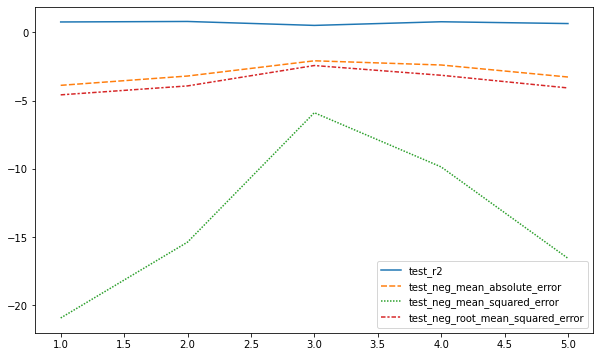

In [86]:
sns.lineplot(data = scores.iloc[:,2:])

In [87]:
lasso_model.coef_

array([ 4.85923069, -0.        ,  4.55207854, -0.53405286, -0.        ,
       -0.        , -0.        ])

In [88]:
lsm_df = pd.DataFrame(lasso_model.coef_, columns = ["lasso_coef_1"])

In [89]:
pd.concat([lm_df, rm_df, rcm_df, lsm_df], axis = 1)

,lm_coef,ridge_coef_1,ridge_cv_coef_0.02,lasso_coef_1
0,5.111,5.079,5.094,4.859
1,-1.019,-0.954,-0.954,-0.000
2,4.834,4.799,4.816,4.552
3,-3.314,-3.166,-3.182,-0.534
4,0.091,0.076,0.080,-0.000
5,-3.511,-3.296,-3.318,-0.000
6,-1.852,-1.737,-1.745,-0.000


In [90]:
lasso_cv_model = LassoCV(alphas = alpha_space, cv = 5, max_iter=100000, random_state=42) 

In [91]:
lasso_cv_model.fit(X_train, y_train)

LassoCV(alphas=array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
       0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22,
       0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33,
       0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44,
       0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54, 0.55,
       0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66,
       0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77,
       0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88,
       0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99,
       1.  ]),
        cv=5, max_iter=100000, random_state=42)

In [92]:
lasso_cv_model.alpha_

0.02

In [93]:
np.where(alpha_space[::-1]==lasso_cv_model.alpha_)

(array([98], dtype=int64),)

In [94]:
alpha_space[::-1]

array([1.  , 0.99, 0.98, 0.97, 0.96, 0.95, 0.94, 0.93, 0.92, 0.91, 0.9 ,
       0.89, 0.88, 0.87, 0.86, 0.85, 0.84, 0.83, 0.82, 0.81, 0.8 , 0.79,
       0.78, 0.77, 0.76, 0.75, 0.74, 0.73, 0.72, 0.71, 0.7 , 0.69, 0.68,
       0.67, 0.66, 0.65, 0.64, 0.63, 0.62, 0.61, 0.6 , 0.59, 0.58, 0.57,
       0.56, 0.55, 0.54, 0.53, 0.52, 0.51, 0.5 , 0.49, 0.48, 0.47, 0.46,
       0.45, 0.44, 0.43, 0.42, 0.41, 0.4 , 0.39, 0.38, 0.37, 0.36, 0.35,
       0.34, 0.33, 0.32, 0.31, 0.3 , 0.29, 0.28, 0.27, 0.26, 0.25, 0.24,
       0.23, 0.22, 0.21, 0.2 , 0.19, 0.18, 0.17, 0.16, 0.15, 0.14, 0.13,
       0.12, 0.11, 0.1 , 0.09, 0.08, 0.07, 0.06, 0.05, 0.04, 0.03, 0.02,
       0.01])

In [95]:
#mse score for CV
lasso_cv_model.mse_path_[99].mean()

7.581468318193802

In [96]:
y_pred = lasso_cv_model.predict(X_test)   #Lasso(alpha =0.01)
y_train_pred = lasso_cv_model.predict(X_train)

In [97]:
lcs = train_val(y_train, y_train_pred, y_test, y_pred, "lasso_cv")
lcs

,lasso_cv_train,lasso_cv_test
R2,0.902,0.822
mae,1.809,2.640
mse,5.656,12.216
rmse,2.378,3.495


In [98]:
pd.concat([ls,rs, rcs, lss, lcs], axis = 1)

,linear_train,linear_test,ridge_train,ridge_test,ridge_cv_train,ridge_cv_test,lasso_train,lasso_test,lasso_cv_train,lasso_cv_test
R2,0.902,0.810,0.902,0.810,0.902,0.812,0.798,0.609,0.902,0.822
mae,1.820,2.709,1.820,2.709,1.822,2.700,2.696,4.122,1.809,2.640
mse,5.655,12.985,5.655,12.985,5.648,12.890,11.596,26.772,5.656,12.216
rmse,2.378,3.604,2.378,3.604,2.376,3.590,3.405,5.174,2.378,3.495


In [99]:
lasso_cv_model.coef_

array([ 5.99648267,  0.        ,  5.83673796, -2.50598714,  0.1773198 ,
       -2.11729172, -0.70663354])

In [100]:
lcm_df = pd.DataFrame(lasso_cv_model.coef_, columns = ["lasso_cv_coef_0.01"])

In [101]:
pd.concat([lm_df, rm_df, rcm_df, lsm_df, lcm_df], axis = 1)

,lm_coef,ridge_coef_1,ridge_cv_coef_0.02,lasso_coef_1,lasso_cv_coef_0.01
0,5.111,5.079,5.094,4.859,5.996
1,-1.019,-0.954,-0.954,-0.000,0.000
2,4.834,4.799,4.816,4.552,5.837
3,-3.314,-3.166,-3.182,-0.534,-2.506
4,0.091,0.076,0.080,-0.000,0.177
5,-3.511,-3.296,-3.318,-0.000,-2.117
6,-1.852,-1.737,-1.745,-0.000,-0.707


## 2.3 Elastic-Net (Apply and evaluate )
* Use Gridsearch for hyperparameter tuning instead of ElacticnetCV

In [102]:
from sklearn.linear_model import ElasticNet, ElasticNetCV

In [103]:
elastic_model = ElasticNet(alpha=1, l1_ratio=0.5, random_state=42)
elastic_model.fit(X_train, y_train)

ElasticNet(alpha=1, random_state=42)

In [104]:
y_pred = elastic_model.predict(X_test)
y_train_pred = elastic_model.predict(X_train)

In [105]:
es = train_val(y_train, y_train_pred, y_test, y_pred, "elastic")
es

,elastic_train,elastic_test
R2,0.652,0.487
mae,3.591,4.766
mse,20.030,35.106
rmse,4.476,5.925


In [106]:
pd.concat([ls,rs, rcs, lss, lcs, es], axis = 1)

,linear_train,linear_test,ridge_train,ridge_test,ridge_cv_train,ridge_cv_test,lasso_train,lasso_test,lasso_cv_train,lasso_cv_test,elastic_train,elastic_test
R2,0.902,0.810,0.902,0.810,0.902,0.812,0.798,0.609,0.902,0.822,0.652,0.487
mae,1.820,2.709,1.820,2.709,1.822,2.700,2.696,4.122,1.809,2.640,3.591,4.766
mse,5.655,12.985,5.655,12.985,5.648,12.890,11.596,26.772,5.656,12.216,20.030,35.106
rmse,2.378,3.604,2.378,3.604,2.376,3.590,3.405,5.174,2.378,3.495,4.476,5.925


In [107]:
model = ElasticNet(alpha=1, l1_ratio=0.5, random_state=42)
scores = cross_validate(model, X_train, y_train,
                        scoring=['r2', 'neg_mean_absolute_error','neg_mean_squared_error','neg_root_mean_squared_error'], cv=5)

In [108]:
scores = pd.DataFrame(scores, index = range(1, 6))
scores.iloc[:,2:]

,test_r2,test_neg_mean_absolute_error,test_neg_mean_squared_error,test_neg_root_mean_squared_error
1,0.578,-5.145,-38.049,-6.168
2,0.584,-4.846,-32.689,-5.717
3,0.359,-2.375,-7.787,-2.790
4,0.611,-3.152,-17.678,-4.205
5,0.499,-4.119,-23.786,-4.877


In [109]:
scores = pd.DataFrame(scores, index = range(1, 11))
scores.iloc[:,2:].mean()

test_r2                              0.526
test_neg_mean_absolute_error        -3.927
test_neg_mean_squared_error        -23.998
test_neg_root_mean_squared_error    -4.752
dtype: float64

In [110]:
train_val(y_train, y_train_pred, y_test, y_pred, "elastic")

,elastic_train,elastic_test
R2,0.652,0.487
mae,3.591,4.766
mse,20.030,35.106
rmse,4.476,5.925


In [111]:
elastic_model.coef_

array([ 2.83950583, -0.55675519,  2.53265604, -1.07355059, -0.        ,
       -0.60340515, -0.57522566])

In [112]:
em_df = pd.DataFrame(elastic_model.coef_, columns=["elastic_coef_(alp:1, l1:0.5)"])

In [113]:
pd.concat([lm_df, rm_df, rcm_df, lsm_df, lcm_df, em_df], axis = 1)

,lm_coef,ridge_coef_1,ridge_cv_coef_0.02,lasso_coef_1,lasso_cv_coef_0.01,"elastic_coef_(alp:1, l1:0.5)"
0,5.111,5.079,5.094,4.859,5.996,2.840
1,-1.019,-0.954,-0.954,-0.000,0.000,-0.557
2,4.834,4.799,4.816,4.552,5.837,2.533
3,-3.314,-3.166,-3.182,-0.534,-2.506,-1.074
4,0.091,0.076,0.080,-0.000,0.177,-0.000
5,-3.511,-3.296,-3.318,-0.000,-2.117,-0.603
6,-1.852,-1.737,-1.745,-0.000,-0.707,-0.575


In [114]:
elastic_cv_model = ElasticNetCV(alphas = alpha_space, l1_ratio=[0.1, 0.5, 0.7,0.9, 0.95, 1], cv = 5, 
                                max_iter = 100000,random_state=42)

In [116]:
elastic_cv_model.fit(X_train, y_train)

ElasticNetCV(alphas=array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
       0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22,
       0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33,
       0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44,
       0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54, 0.55,
       0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66,
       0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77,
       0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88,
       0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99,
       1.  ]),
             cv=5, l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1], max_iter=100000,
             random_state=42)

In [117]:
elastic_cv_model.alpha_

0.04

In [118]:
elastic_cv_model.l1_ratio_

0.9

In [119]:
#mse score for CV
elastic_cv_model.mse_path_[5][-1].mean()

7.581468318193802

In [120]:
y_pred = elastic_cv_model.predict(X_test)
y_train_pred = elastic_cv_model.predict(X_train)

In [121]:
ecs = train_val(y_train, y_train_pred, y_test, y_pred, "elastic_cv")
ecs

,elastic_cv_train,elastic_cv_test
R2,0.901,0.816
mae,1.803,2.683
mse,5.677,12.579
rmse,2.383,3.547


In [122]:
pd.concat([ls,rs, rcs, lss, lcs, es, ecs], axis = 1)

,linear_train,linear_test,ridge_train,ridge_test,ridge_cv_train,ridge_cv_test,lasso_train,lasso_test,lasso_cv_train,lasso_cv_test,elastic_train,elastic_test,elastic_cv_train,elastic_cv_test
R2,0.902,0.810,0.902,0.810,0.902,0.812,0.798,0.609,0.902,0.822,0.652,0.487,0.901,0.816
mae,1.820,2.709,1.820,2.709,1.822,2.700,2.696,4.122,1.809,2.640,3.591,4.766,1.803,2.683
mse,5.655,12.985,5.655,12.985,5.648,12.890,11.596,26.772,5.656,12.216,20.030,35.106,5.677,12.579
rmse,2.378,3.604,2.378,3.604,2.376,3.590,3.405,5.174,2.378,3.495,4.476,5.925,2.383,3.547


In [123]:
elastic_cv_model.coef_

array([ 5.94285041, -0.        ,  5.77337823, -2.45275789,  0.14647045,
       -2.04451334, -0.67713696])

In [124]:
ecm_df = pd.DataFrame(elastic_cv_model.coef_, columns=["elastic_coef_(alp:0.01, l1:1)"])

In [125]:
pd.concat([lm_df, rm_df, rcm_df, lsm_df, lcm_df, em_df, ecm_df], axis = 1)

,lm_coef,ridge_coef_1,ridge_cv_coef_0.02,lasso_coef_1,lasso_cv_coef_0.01,"elastic_coef_(alp:1, l1:0.5)","elastic_coef_(alp:0.01, l1:1)"
0,5.111,5.079,5.094,4.859,5.996,2.840,5.943
1,-1.019,-0.954,-0.954,-0.000,0.000,-0.557,-0.000
2,4.834,4.799,4.816,4.552,5.837,2.533,5.773
3,-3.314,-3.166,-3.182,-0.534,-2.506,-1.074,-2.453
4,0.091,0.076,0.080,-0.000,0.177,-0.000,0.146
5,-3.511,-3.296,-3.318,-0.000,-2.117,-0.603,-2.045
6,-1.852,-1.737,-1.745,-0.000,-0.707,-0.575,-0.677


In [126]:
from sklearn.model_selection import GridSearchCV

In [127]:
elastic_model = ElasticNet(max_iter=10000, random_state=42)

In [128]:
param_grid = {"alpha":[0.01, 0.012, 0.2, 0.5, 0.6, 0.7, 1],
            "l1_ratio":[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1]}

In [129]:
grid_model = GridSearchCV(estimator = elastic_model, param_grid = param_grid, scoring = 'neg_root_mean_squared_error',
                         cv =5, verbose =2)

In [130]:
grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 49 candidates, totalling 245 fits
[CV] END ...........................alpha=0.01, l1_ratio=0.1; total time=   0.0s
[CV] END ...........................alpha=0.01, l1_ratio=0.1; total time=   0.0s
[CV] END ...........................alpha=0.01, l1_ratio=0.1; total time=   0.0s
[CV] END ...........................alpha=0.01, l1_ratio=0.1; total time=   0.0s
[CV] END ...........................alpha=0.01, l1_ratio=0.1; total time=   0.0s
[CV] END ...........................alpha=0.01, l1_ratio=0.5; total time=   0.0s
[CV] END ...........................alpha=0.01, l1_ratio=0.5; total time=   0.0s
[CV] END ...........................alpha=0.01, l1_ratio=0.5; total time=   0.0s
[CV] END ...........................alpha=0.01, l1_ratio=0.5; total time=   0.0s
[CV] END ...........................alpha=0.01, l1_ratio=0.5; total time=   0.0s
[CV] END ...........................alpha=0.01, l1_ratio=0.7; total time=   0.0s
[CV] END ...........................alpha=0.01,

[CV] END ............................alpha=0.5, l1_ratio=0.7; total time=   0.0s
[CV] END ............................alpha=0.5, l1_ratio=0.9; total time=   0.0s
[CV] END ............................alpha=0.5, l1_ratio=0.9; total time=   0.0s
[CV] END ............................alpha=0.5, l1_ratio=0.9; total time=   0.0s
[CV] END ............................alpha=0.5, l1_ratio=0.9; total time=   0.0s
[CV] END ............................alpha=0.5, l1_ratio=0.9; total time=   0.0s
[CV] END ...........................alpha=0.5, l1_ratio=0.95; total time=   0.0s
[CV] END ...........................alpha=0.5, l1_ratio=0.95; total time=   0.0s
[CV] END ...........................alpha=0.5, l1_ratio=0.95; total time=   0.0s
[CV] END ...........................alpha=0.5, l1_ratio=0.95; total time=   0.0s
[CV] END ...........................alpha=0.5, l1_ratio=0.95; total time=   0.0s
[CV] END ...........................alpha=0.5, l1_ratio=0.99; total time=   0.0s
[CV] END ...................

[CV] END ................................alpha=1, l1_ratio=1; total time=   0.0s
[CV] END ................................alpha=1, l1_ratio=1; total time=   0.0s
[CV] END ................................alpha=1, l1_ratio=1; total time=   0.0s
[CV] END ................................alpha=1, l1_ratio=1; total time=   0.0s
[CV] END ................................alpha=1, l1_ratio=1; total time=   0.0s


GridSearchCV(cv=5, estimator=ElasticNet(max_iter=10000, random_state=42),
             param_grid={'alpha': [0.01, 0.012, 0.2, 0.5, 0.6, 0.7, 1],
                         'l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1]},
             scoring='neg_root_mean_squared_error', verbose=2)

In [131]:
grid_model.best_params_

{'alpha': 0.012, 'l1_ratio': 0.1}

In [132]:
pd.DataFrame(grid_model.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.002,0.000,0.001,0.001,0.010,0.100,"{'alpha': 0.01, 'l1_ratio': 0.1}",-2.425,-2.809,-3.138,-2.772,-2.513,-2.731,0.251,2
1,0.002,0.001,0.001,0.000,0.010,0.500,"{'alpha': 0.01, 'l1_ratio': 0.5}",-2.406,-2.833,-3.148,-2.786,-2.497,-2.734,0.264,8
2,0.002,0.000,0.001,0.000,0.010,0.700,"{'alpha': 0.01, 'l1_ratio': 0.7}",-2.395,-2.848,-3.153,-2.798,-2.489,-2.737,0.271,11
3,0.002,0.000,0.001,0.000,0.010,0.900,"{'alpha': 0.01, 'l1_ratio': 0.9}",-2.383,-2.856,-3.155,-2.804,-2.483,-2.736,0.277,10
4,0.002,0.000,0.001,0.000,0.010,0.950,"{'alpha': 0.01, 'l1_ratio': 0.95}",-2.379,-2.864,-3.155,-2.805,-2.481,-2.737,0.279,12
5,0.000,0.001,0.000,0.000,0.010,0.990,"{'alpha': 0.01, 'l1_ratio': 0.99}",-2.376,-2.872,-3.154,-2.806,-2.480,-2.738,0.281,13
6,0.000,0.000,0.003,0.006,0.010,1,"{'alpha': 0.01, 'l1_ratio': 1}",-2.375,-2.875,-3.154,-2.806,-2.479,-2.738,0.281,14
7,0.000,0.000,0.003,0.006,0.012,0.100,"{'alpha': 0.012, 'l1_ratio': 0.1}",-2.432,-2.801,-3.129,-2.768,-2.519,-2.730,0.245,1
8,0.000,0.000,0.003,0.006,0.012,0.500,"{'alpha': 0.012, 'l1_ratio': 0.5}",-2.409,-2.826,-3.141,-2.783,-2.500,-2.732,0.260,3
9,0.000,0.000,0.003,0.006,0.012,0.700,"{'alpha': 0.012, 'l1_ratio': 0.7}",-2.396,-2.844,-3.146,-2.797,-2.492,-2.735,0.268,9


In [133]:
grid_model.best_index_

7

In [134]:
grid_model.best_score_

-2.7300058228946895

In [135]:
y_pred = grid_model.predict(X_test)
y_train_pred = grid_model.predict(X_train)

In [136]:
train_val(y_train, y_train_pred, y_test, y_pred, "GridSearch")

,GridSearch_train,GridSearch_test
R2,0.902,0.812
mae,1.821,2.696
mse,5.647,12.853
rmse,2.376,3.585
